# Code to determine the Correlations metric


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import scipy.stats as stats

base_dir = Path().resolve()
print(base_dir)

# utilized in upset_frequency
def load_all_league_data():
    """
    Load match data and standings for all available leagues.
    
    Returns:
        tuple: (league_data_dict, standings_dict) where each is a dict of league_name -> DataFrame
    """
    base_dir = Path().resolve()
    
    # Define league configurations
    leagues = {
        'Premier League': {
            'matches_file': 'premier_league_actual.csv',
            'standings_file': 'premier_league_standings_all_seasons.csv'
        },
        'Serie A': {
            'matches_file': 'serie_a_actual.csv',
            'standings_file': 'serie_a_standings_all_seasons.csv'
        },
        'Bundesliga': {
            'matches_file': 'bundesliga_actual.csv',
            'standings_file': 'bundesliga_standings_all_seasons.csv'
        },
        'La Liga': {
            'matches_file': 'la_liga_actual.csv',
            'standings_file': 'la_liga_standings_all_seasons.csv'
        }
    }
    
    league_data = {}
    standings_data = {}
    
    print("Loading league data...")   
    for league_name, config in leagues.items():
        # Load match data
        matches_path = base_dir / "../../../../data/european_soccer_leagues/actual" / config['matches_file']
        if matches_path.exists():
            matches_df = pd.read_csv(matches_path)
            matches_df['date'] = pd.to_datetime(matches_df['date'])
            league_data[league_name] = matches_df
            print(f"✓ Loaded {league_name} matches: {len(matches_df):,} matches")
        else:
            print(f"✗ Warning: {matches_path} not found")
            
        # Load standings data
        standings_path = base_dir / "../../../../data/european_soccer_leagues/actual" / config['standings_file']
        if standings_path.exists():
            standings_df = pd.read_csv(standings_path)
            standings_data[league_name] = standings_df
            print(f"✓ Loaded {league_name} standings: {len(standings_df):,} team-seasons")
        else:
            print(f"✗ Warning: {standings_path} not found")
    
    print(f"\nSuccessfully loaded {len(league_data)} leagues")
    return league_data, standings_data
league_data, standings_data = load_all_league_data()


/Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations
Loading league data...
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/premier_league_actual.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/premier_league_standings_all_seasons.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/serie_a_actual.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/serie_a_standings_all_seasons.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/bundesliga_actual.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/co

In [3]:

results = []
def goal_calculation(team, games):
    home_points = games.loc[games["home_team"] == team, "home_team_points"].sum() #sum up every home games points
    away_points = games.loc[games["away_team"] == team, "away_team_points"].sum() #sum up every away games points
    return home_points + away_points


def correlation(team,season, matches_played):
    df = matches_played[matches_played["season"] == season]
    df = df[(df["home_team"] == team) | (df["away_team"] == team)]
    df = df.sort_values(by = "date", ascending= True)
    midpoint = len(df) // 2
    first_half = df.iloc[:midpoint]
    second_half = df.iloc[midpoint:]
    first_half_points = goal_calculation(team, first_half)
    second_half_points = goal_calculation(team, second_half)
    first_half_points = (first_half_points/len(first_half))/ 3 * 100
    second_half_points = (second_half_points/len(second_half)) / 3 * 100
    dictionary= {"team": team, "season": season, "first_half_points": first_half_points, "second_half_points": second_half_points}

    return dictionary

skilled_leagues = pd.read_csv("/Users/joeyli/skillvsluck/data/european_soccer_leagues/pure_skill/skill_based_league.csv")

for league in league_data:
    # df = league_data[league] normal leagues
    df = skilled_leagues[skilled_leagues["league"] ==league].copy() # skilled leagues
    unique_pairs = set(zip(df["season"], df["home_team"]))
    for season, team in unique_pairs:
        second=correlation(team, season, df)
        second["league"] = league
        results.append(second)
allleagues = pd.DataFrame(results)
allleagues=allleagues.sort_values(by = ["league", "season", "team"], ascending= True)

KeyError: 'league'

In [ ]:
allleagues=allleagues.sort_values(by = ["league", "season", "team"], ascending= True)
# allleagues.to_csv("correlation_metrics.csv", index=False)
allleagues.to_csv("first_second_win_pct_all_seeds.csv", index=False)
allleagues


,team,season,first_half_points,second_half_points,league
910,BAY,2004,100.000000,100.000000,Bundesliga
1068,BIE,2004,29.411765,29.411765,Bundesliga
1029,BOC,2004,11.764706,11.764706,Bundesliga
936,DOR,2004,64.705882,64.705882,Bundesliga
894,FRE,2004,0.000000,0.000000,Bundesliga
...,...,...,...,...,...
878,ROM,2024,78.947368,78.947368,Serie A
575,TOR,2024,47.368421,47.368421,Serie A
874,UDI,2024,42.105263,42.105263,Serie A
574,VEN,2024,5.263158,5.263158,Serie A


In [9]:
# Testing the spearman correlations
league_data = ["Bundesliga", "Premier League", "Serie A", "La Liga"]
allleagues = pd.read_csv("/Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/match_data_correlations/actual_win_pct.csv")
for league in league_data:
    #df = league_data[league] #normal leagues
    df = allleagues[allleagues["league"] ==league].copy() # skilled leagues
    spearman = df.drop(columns=["league", "team", "season"])
    corr = spearman.corr("spearman").iloc[1, 0].round(4)
    print(corr)
print(allleagues)


0.5546
0.6531
0.6361
0.5074
     team  season  first_half_win_pct  second_half_win_pct      league
0     BAY    2004           66.666667            84.313725  Bundesliga
1     BIE    2004           47.058824            31.372549  Bundesliga
2     BOC    2004           27.450980            41.176471  Bundesliga
3     DOR    2004           35.294118            72.549020  Bundesliga
4     FRE    2004           21.568627            13.725490  Bundesliga
...   ...     ...                 ...                  ...         ...
1727  ROM    2024           40.350877            80.701754     Serie A
1728  TOR    2024           36.842105            40.350877     Serie A
1729  UDI    2024           43.859649            33.333333     Serie A
1730  VEN    2024           24.561404            26.315789     Serie A
1731  VER    2024           33.333333            31.578947     Serie A

[1732 rows x 5 columns]


# Create Plots

     team  season  first_half_win_pct  second_half_win_pct      league
0     BAY    2004           66.666667            84.313725  Bundesliga
1     BIE    2004           47.058824            31.372549  Bundesliga
2     BOC    2004           27.450980            41.176471  Bundesliga
3     DOR    2004           35.294118            72.549020  Bundesliga
4     FRE    2004           21.568627            13.725490  Bundesliga
...   ...     ...                 ...                  ...         ...
1727  ROM    2024           40.350877            80.701754     Serie A
1728  TOR    2024           36.842105            40.350877     Serie A
1729  UDI    2024           43.859649            33.333333     Serie A
1730  VEN    2024           24.561404            26.315789     Serie A
1731  VER    2024           33.333333            31.578947     Serie A

[1732 rows x 5 columns]


/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_24137/295113124.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_24137/295113124.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_24137/295113124.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_24137/295113124.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


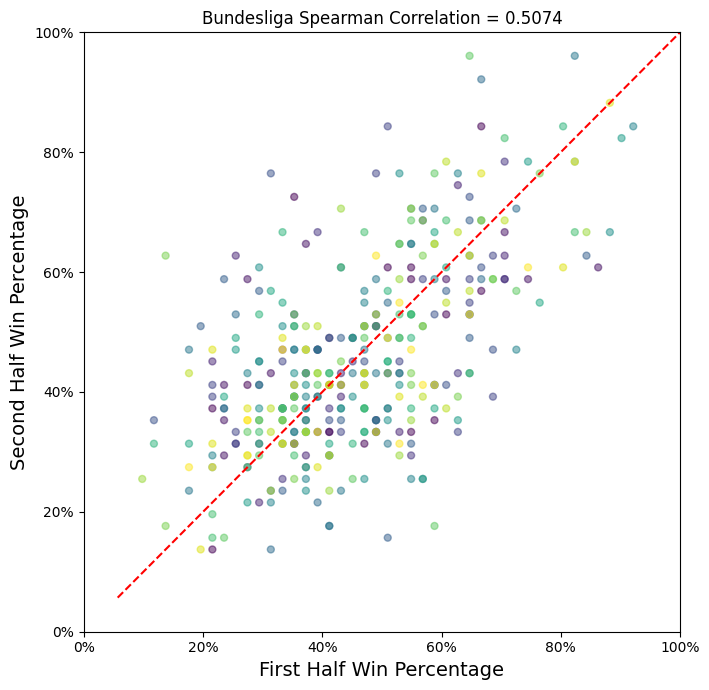

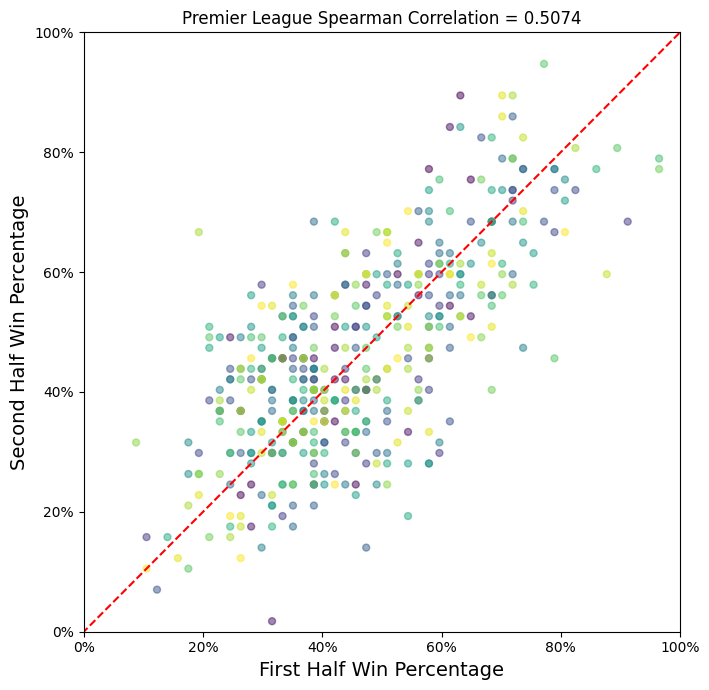

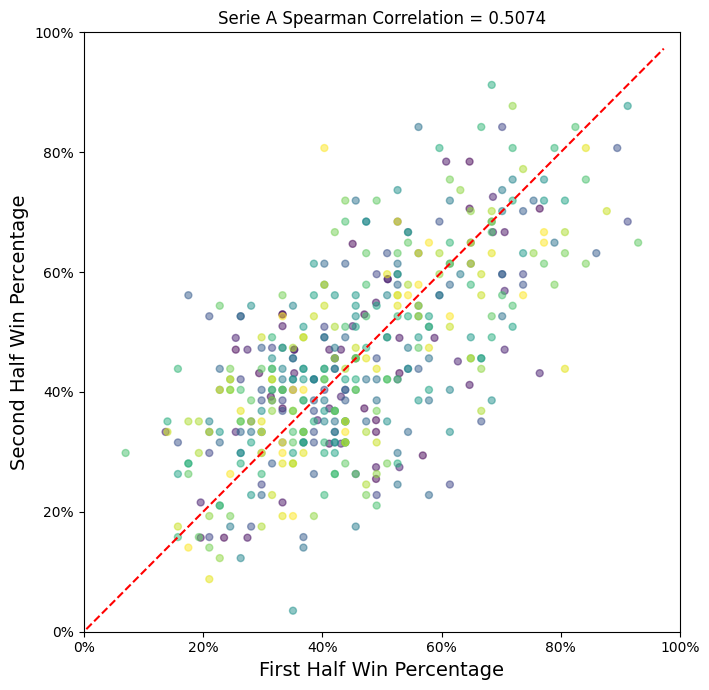

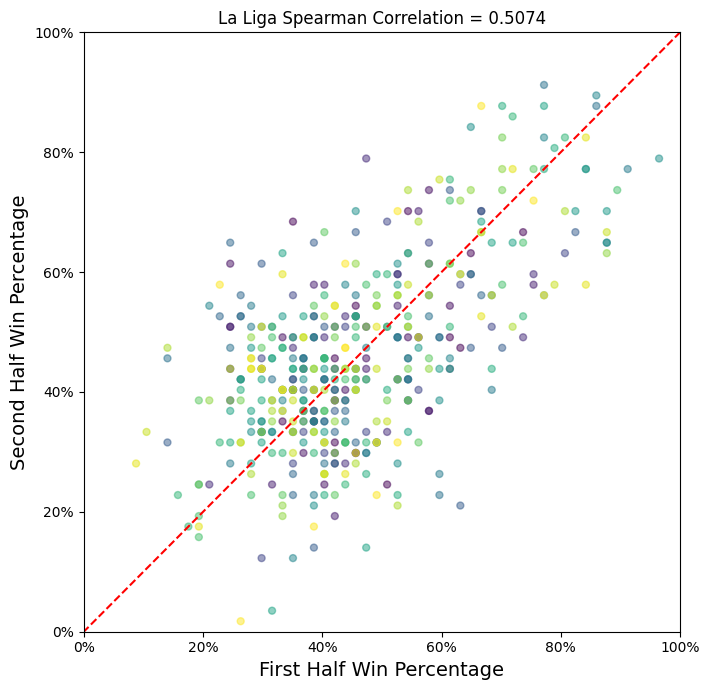

In [10]:
print(allleagues)
import matplotlib.ticker as mtick
league_data = ["Bundesliga", "Premier League", "Serie A", "La Liga"]
out = []
for league in league_data:
    fig, ax = plt.subplots(figsize=(7,7), constrained_layout=True)
    df = allleagues[allleagues["league"] == league].copy()
    df["season"] = df["season"].astype(int)
    # spearman = df.drop(columns=["league", "team", "season", "n_first","n_second"])
    r_s, p_s = stats.spearmanr(df["first_half_win_pct"], df["second_half_win_pct"])
        
        #/ by points per game and divide by 3 to get win percentage
    out.append({
            'league': league,
            'spearman_r': r_s,
            'spearman_p': p_s,
        })

    df.plot(
        x="first_half_win_pct", y="second_half_win_pct", kind="scatter", ax=ax, marker='o', alpha=0.5, s=25,          # circle marker
        c=df["season"],  # 'c' instead of 'color' for a color map
        cmap="viridis"
    )
    
    # Remove the automatic colorbar
    for cbar in ax.figure.axes:
        if cbar is not ax:  # any other axes besides main one
            cbar.remove()
    # ax.set_aspect('equal', adjustable='box')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    min_val = min(plt.xlim()[0], plt.ylim()[0])
    max_val = max(plt.xlim()[1], plt.ylim()[1])
    line_vals = np.linspace(min_val, max_val, 100) # Generate points for the line
    plt.xlim(0, 100)
    plt.ylim(0, 100)

# Plot the y=x line
    plt.plot(line_vals, line_vals, color='red', linestyle='--', label='y=x')
    plt.title(f"{league} Spearman Correlation = {corr}")
    plt.xlabel("First Half Win Percentage", fontsize = 14)
    plt.ylabel("Second Half Win Percentage", fontsize = 14)
    plt.tight_layout()
    # plt.savefig(f"skill_{league.replace(' ', '_').lower()}_correlation.png")

pd.DataFrame(out).sort_values('league').to_csv("spearman_first_second_correlations_by_league.csv", index=False)



In [ ]:
import pandas as pd
from pathlib import Path

base_dir = Path("/Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/pure_luck_result_based")
csv_files = sorted(base_dir.glob("*_seed_*.csv"))

dfs = []

for file in csv_files:
    name_parts = file.stem.split("_")

    # Extract league name (everything before "first")
    if "first" in name_parts:
        league_parts = name_parts[:name_parts.index("first")]
    else:
        league_parts = name_parts[:-2]  # fallback

    league = " ".join(league_parts).title()

    # ✅ Extract seed value
    if "seed" in name_parts:
        seed_index = name_parts.index("seed")
        seed = int(name_parts[seed_index + 1])
    else:
        seed = None

    # Load CSV and add metadata
    df = pd.read_csv(file)
    df["league"] = league
    df["seed"] = seed

    dfs.append(df)
    print(f"✓ Loaded {league} seed {seed} ({len(df)} rows)")

# Combine everything
combined_df = pd.concat(dfs, ignore_index=True)

print(f"\n✅ Combined shape: {combined_df.shape}")
print(combined_df.head())

# Optional: save
output_path = base_dir / "all_leagues_combined_with_seed.csv"
# combined_df.to_csv(output_path, index=False)
print(f"\nSaved combined CSV to: {output_path}")
combined_df



✓ Loaded Bundesliga seed 1 (378 rows)
✓ Loaded Bundesliga seed 2 (378 rows)
✓ Loaded La Liga seed 1 (460 rows)
✓ Loaded La Liga seed 2 (460 rows)
✓ Loaded Premier League seed 1 (440 rows)
✓ Loaded Premier League seed 2 (440 rows)
✓ Loaded Serie A seed 1 (454 rows)
✓ Loaded Serie A seed 2 (454 rows)

✅ Combined shape: (3464, 8)
       league  season team  first_half_win_pct  second_half_win_pct  n_first  \
0  Bundesliga    2004  BAY            0.529412             0.352941     17.0   
1  Bundesliga    2004  BIE            0.470588             0.352941     17.0   
2  Bundesliga    2004  BOC            0.529412             0.117647     17.0   
3  Bundesliga    2004  DOR            0.176471             0.352941     17.0   
4  Bundesliga    2004  FRE            0.176471             0.411765     17.0   

   n_second  seed  
0      17.0     1  
1      17.0     1  
2      17.0     1  
3      17.0     1  
4      17.0     1  

Saved combined CSV to: /Users/joeyli/skillvsluck/output/european_socc

,league,season,team,first_half_win_pct,second_half_win_pct,n_first,n_second,seed
0,Bundesliga,2004,BAY,0.529412,0.352941,17.0,17.0,1
1,Bundesliga,2004,BIE,0.470588,0.352941,17.0,17.0,1
2,Bundesliga,2004,BOC,0.529412,0.117647,17.0,17.0,1
3,Bundesliga,2004,DOR,0.176471,0.352941,17.0,17.0,1
4,Bundesliga,2004,FRE,0.176471,0.411765,17.0,17.0,1
...,...,...,...,...,...,...,...,...
3459,Serie A,2024,ROM,0.421053,0.315789,19.0,19.0,2
3460,Serie A,2024,TOR,0.526316,0.526316,19.0,19.0,2
3461,Serie A,2024,UDI,0.368421,0.210526,19.0,19.0,2
3462,Serie A,2024,VEN,0.315789,0.315789,19.0,19.0,2


In [5]:
df = combined_df[(combined_df["league"] == league) & (combined_df["seed"] == seed)].copy()
print(df)

       league  season  team  first_half_win_pct  second_half_win_pct  n_first  \
3010  Serie A    2000   ATA            0.294118             0.117647     17.0   
3011  Serie A    2000  BARI            0.470588             0.411765     17.0   
3012  Serie A    2000  BOLG            0.352941             0.294118     17.0   
3013  Serie A    2000  BRES            0.176471             0.411765     17.0   
3014  Serie A    2000   FIO            0.411765             0.411765     17.0   
...       ...     ...   ...                 ...                  ...      ...   
3459  Serie A    2024   ROM            0.421053             0.315789     19.0   
3460  Serie A    2024   TOR            0.526316             0.526316     19.0   
3461  Serie A    2024   UDI            0.368421             0.210526     19.0   
3462  Serie A    2024   VEN            0.315789             0.315789     19.0   
3463  Serie A    2024   VER            0.421053             0.210526     19.0   

      n_second  seed  
3010

/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_41868/3417018244.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_41868/3417018244.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_41868/3417018244.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_41868/3417018244.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_41868/3417018244.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_41868/3417018244.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_41868

,league,spearman_r,spearman_p,seed
0,Bundesliga,-0.053563,0.298953,1
6,La Liga,0.024103,0.606115,1
2,Premier League,0.001988,0.966833,1
4,Serie A,-0.008234,0.861100,1
1,Bundesliga,0.071331,0.166357,2
7,La Liga,-0.022900,0.624227,2
3,Premier League,0.012535,0.793162,2
5,Serie A,-0.087985,0.061041,2


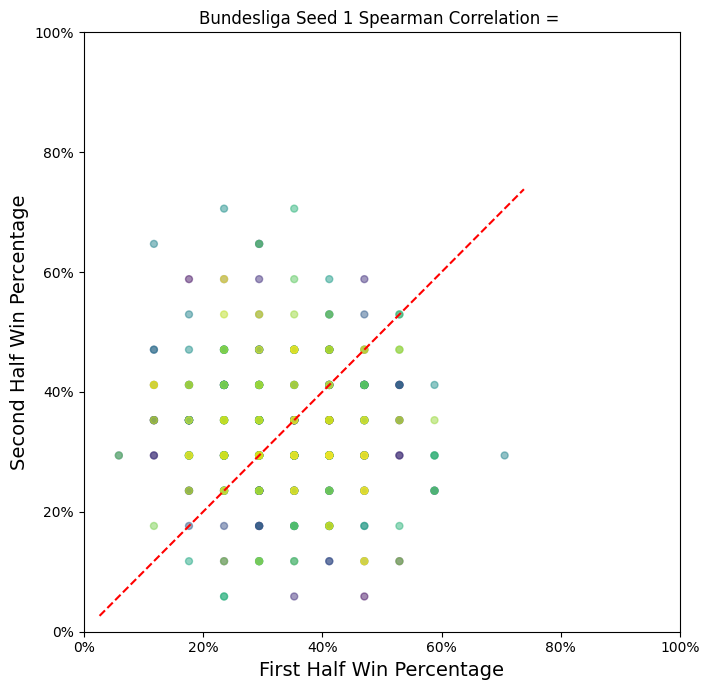

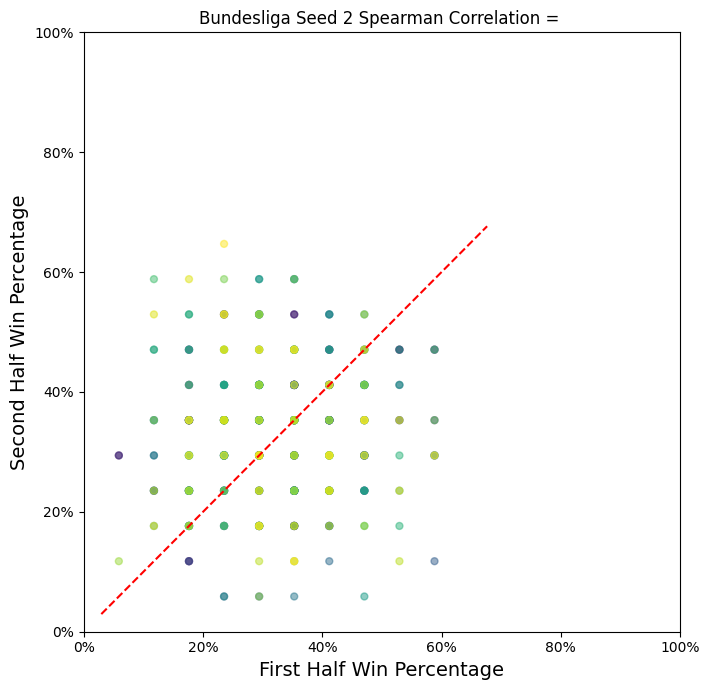

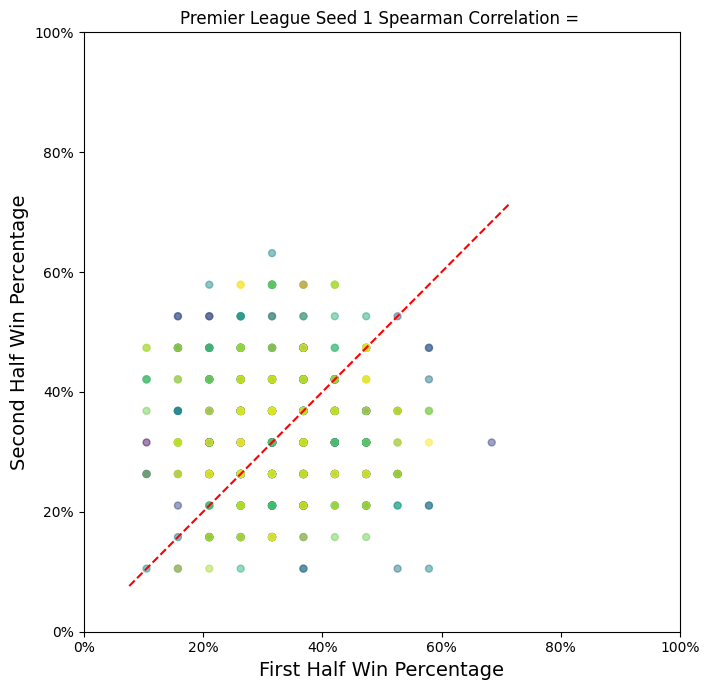

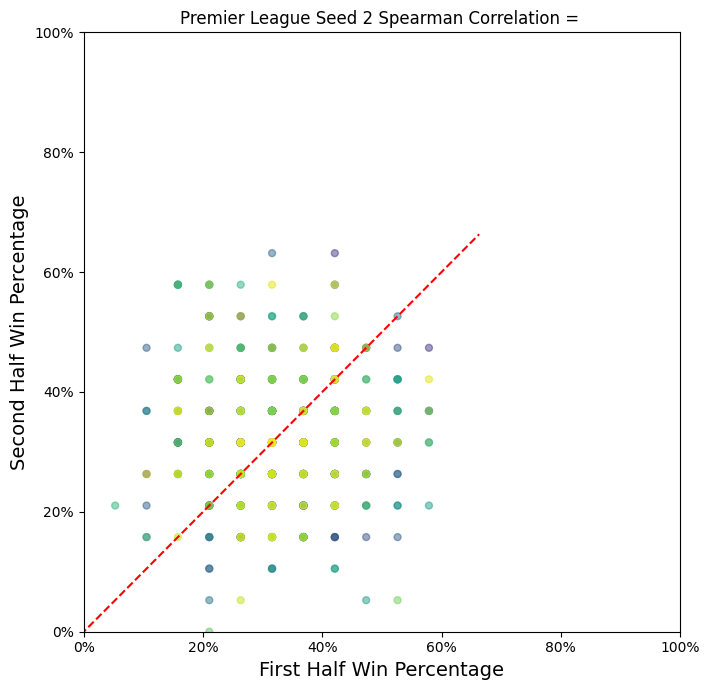

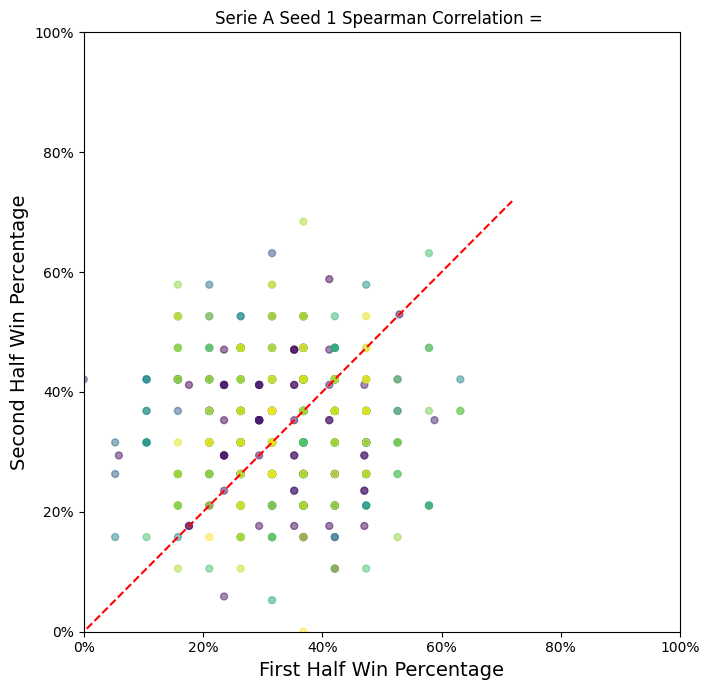

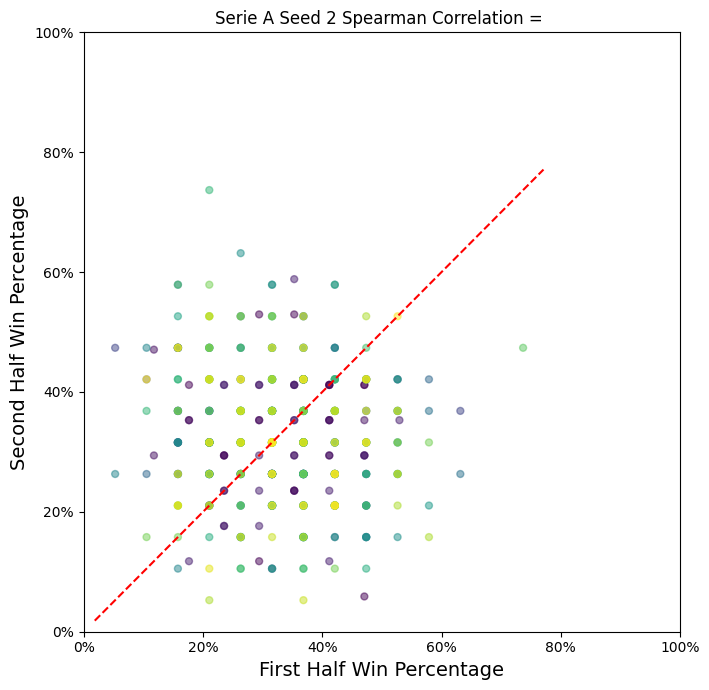

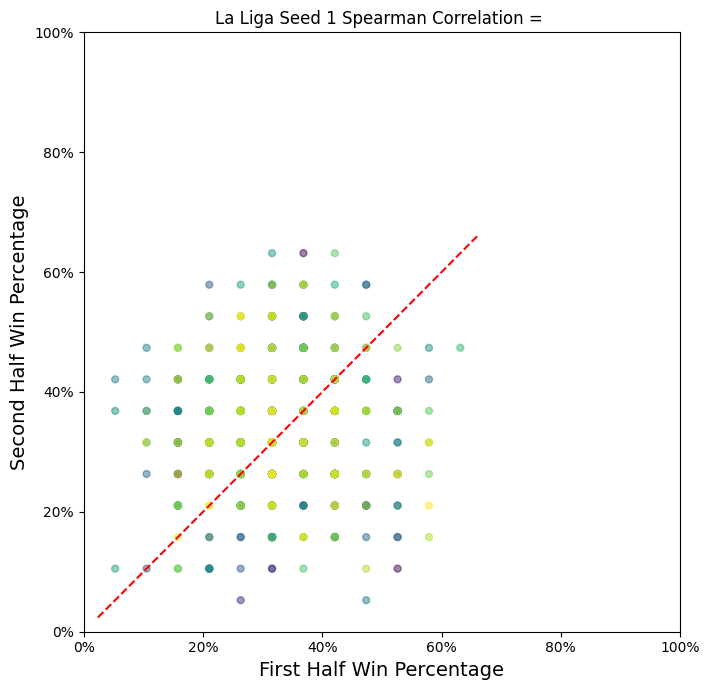

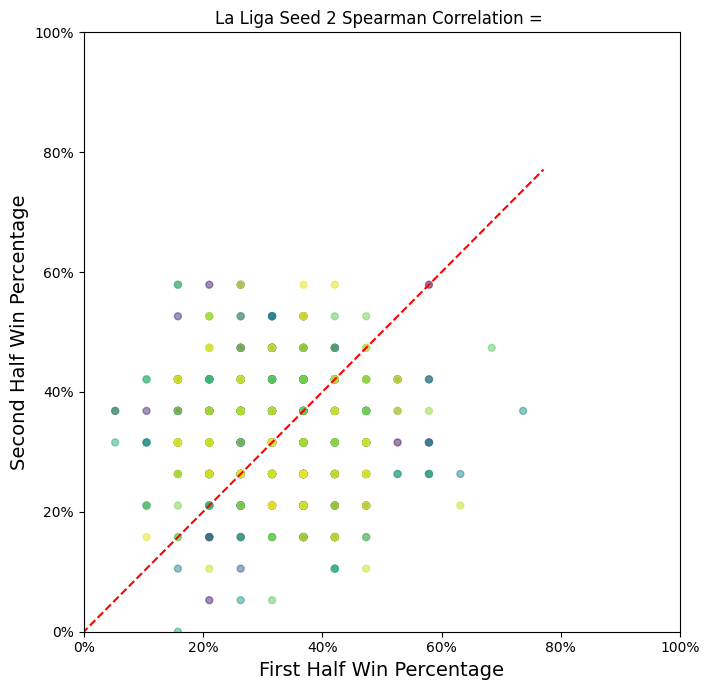

In [ ]:
import matplotlib.ticker as mtick
import scipy.stats as stats
out = []
league_data = ["Bundesliga", "Premier League", "Serie A", "La Liga"]
for league in league_data:
    for seed in [1, 2]:
        fig, ax = plt.subplots(figsize=(7,7), constrained_layout=True)
        df = combined_df[(combined_df["league"] == league) & (combined_df["seed"] == seed)].copy()
        df["season"] = df["season"].astype(int)
        df["first_half_win_pct"] = df["first_half_win_pct"] * 100
        df["second_half_win_pct"] = df["second_half_win_pct"] * 100
        spearman = df.drop(columns=["league", "team", "season", "n_first","n_second", "seed"])
        r_s, p_s = stats.spearmanr(df["first_half_win_pct"], df["second_half_win_pct"])
        
        #/ by points per game and divide by 3 to get win percentage
        out.append({
                'league': league,
                'spearman_r': r_s,
                'spearman_p': p_s,
                'seed': seed
            })

        df.plot(
            x="first_half_win_pct", y="second_half_win_pct", kind="scatter", ax=ax, marker='o', alpha=0.5, s=25,          # circle marker
            c=df["season"],  # 'c' instead of 'color' for a color map
            cmap="viridis"
        )
        
        # Remove the automatic colorbar
        for cbar in ax.figure.axes:
            if cbar is not ax:  # any other axes besides main one
                cbar.remove()
        # ax.set_aspect('equal', adjustable='box')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

        min_val = min(plt.xlim()[0], plt.ylim()[0])
        max_val = max(plt.xlim()[1], plt.ylim()[1])
        line_vals = np.linspace(min_val, max_val, 100) # Generate points for the line
        plt.xlim(0, 100)
        plt.ylim(0, 100)

    # Plot the y=x line
        plt.plot(line_vals, line_vals, color='red', linestyle='--', label='y=x')
        plt.title(f"{league} Seed {seed} Spearman Correlation = ")
        plt.xlabel("First Half Win Percentage", fontsize = 14)
        plt.ylabel("Second Half Win Percentage", fontsize = 14)
        plt.tight_layout()
        # plt.savefig(f"{league.replace(' ', '_').lower()}_first_second_win_pct_seed_{seed}.png")
pd.DataFrame(out).sort_values(['seed','league']).to_csv("overall_correlations_pure_luck")



In [ ]:
# ============================================================
# Predictive Persistence Analysis (league-selectable) NEW CODE
# ============================================================

# 0) Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as mtick
# define function which plots first-half and second-half win percentage
# for all teams in one season
def plot_season_scatter(grp, season):
    # compute Spearman rank correlation and p_value between first half and second half win percentage
    r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
    plt.figure(figsize=(6,6)) # creates square figure
    plt.scatter(grp['first'], grp['second'], color='blue') # plots one point per team
    # draw y = x line
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    # fix x and y axis to [0,1], label axes, title graph
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'Predictive Persistence {LEAGUE} – {season}\nSpearman r={r_s:.2f}, p={p_s:.3f}')
    plt.legend() # shows label on y = x line
    plt.show()

# define function which takes output of compute_first_second_halves (one row per team-season
# with 'first' and 'second' win percentages) and computes a per-season Spearman correlation.
def season_correlations(first_second_df):
    out = []  # collect one dict per season with Spearman stats
    league_data = ["Bundesliga", "Premier League", "Serie A", "La Liga"]

    for league in league_data:
        df = first_second_df[first_second_df["league"] == league].copy()
        for season, grp in df.groupby('season'):
            # Need variation and enough teams; otherwise correlation is undefined or meaningless
            if grp['first_half_points'].nunique() <= 1 or grp['second_half_points'].nunique() <= 1 or len(grp) < 3:
                continue
            # rank each array
            r_s, p_s = stats.spearmanr(grp['first_half_points'], grp['second_half_points'])
            out.append({
                'league': league,
                'season': season,
                'n_teams': len(grp),
                'spearman_r': r_s,
                'spearman_p': p_s
            })
      # store stats for the season: number of teams,
      # spearman r-val (correlation between first half and second half win %
      # across teams in that season), p-val
    return pd.DataFrame(out).sort_values('season')

def seeded_season_correlations(first_second_df):
    out = []  # collect one dict per season with Spearman stats
    for seed in range(1,3):
        print(seed)
        df = first_second_df[first_second_df["seed"] == seed].copy()
        for season, grp in df.groupby('season'):
            # Need variation and enough teams; otherwise correlation is undefined or meaningless
            if grp['first_half_win_pct'].nunique() <= 1 or grp['second_half_win_pct'].nunique() <= 1 or len(grp) < 3:
                continue
            # rank each array
            r_s, p_s = stats.spearmanr(grp['first_half_win_pct'], grp['second_half_win_pct'])
            out.append({
                'season': season,
                'n_teams': len(grp),
                'spearman_r': r_s,
                'spearman_p': p_s
            })
      # store stats for the season: number of teams,
      # spearman r-val (correlation between first half and second half win %
      # across teams in that season), p-val
    return pd.DataFrame(out).sort_values('season')


# ------------------------------------------------------------
# 4) Run predictive persistence analysis
# ------------------------------------------------------------

# get per team per season summaries
fs_win_skill = pd.read_csv("/Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/pure_skill/first_second_win_pct_all_seeds.csv")
# give the summaries to the correlation helper
corr_win_skill = season_correlations(fs_win_skill).sort_values(['league', 'season'])


# ------------------------------------------------------------
# 4) Run predictive persistence analysis
# ------------------------------------------------------------

# get per team per season summaries
fs_win_sim = pd.read_csv("/Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/pure_luck_result_based/all_leagues_combined_with_seed.csv")
# give the summaries to the correlation helper
corr_win_sim = seeded_season_correlations(fs_win_sim)

